In [1]:
# Install required packages
%pip install tensorflow numpy matplotlib seaborn scikit-learn pandas

# Long Short-Term Memory (LSTM) Model with TensorFlow/Keras

This notebook implements an LSTM-based model using TensorFlow/Keras for sentiment analysis on the IMDB movie reviews dataset.

## Objectives:
- Load and preprocess the IMDB dataset
- Build an LSTM model architecture
- Train with different optimizers (SGD, Adam, RMSProp)
- Apply regularization techniques (Dropout, L1/L2, EarlyStopping)
- Perform basic hyperparameter tuning
- Visualize training curves and confusion matrix
- Evaluate model performance
- Save the trained model

In [2]:
# Import Required Libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import pandas as pd
import os
from collections import Counter

In [3]:
# Dataset Loading Function
def load_imdb_dataset():
    """
    Load IMDB dataset from TensorFlow/Keras
    """
    print("Loading IMDB dataset from TensorFlow/Keras...")
    # Load IMDB dataset
    (train_data, train_labels), (test_data, test_labels) = keras.datasets.imdb.load_data(num_words=10000)
    return (train_data, train_labels), (test_data, test_labels)

# Load the dataset
(train_data, train_labels), (test_data, test_labels) = load_imdb_dataset()
print("Dataset loaded successfully!")

Loading IMDB dataset from TensorFlow/Keras...
17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Dataset loaded successfully!


Dataset Info:
Train data shape: 25000
Train labels shape: 25000
Test data shape: 25000
Test labels shape: 25000
1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

Sample Data:
Review 1: ? this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you...
Label 1: Positive

Review 2: ? big hair big boobs bad music and a giant safety pin these are the words to best describe this...
Label 2: Negative

Review 3: ? this has to be one of the worst films of the 1990s when my friends i were watching this...
Label 3: Negative

Label Distribution:
Train set:
  Negative: 12500
  Positive: 12500
Test set:
  Negative: 12500
  Positive: 12500


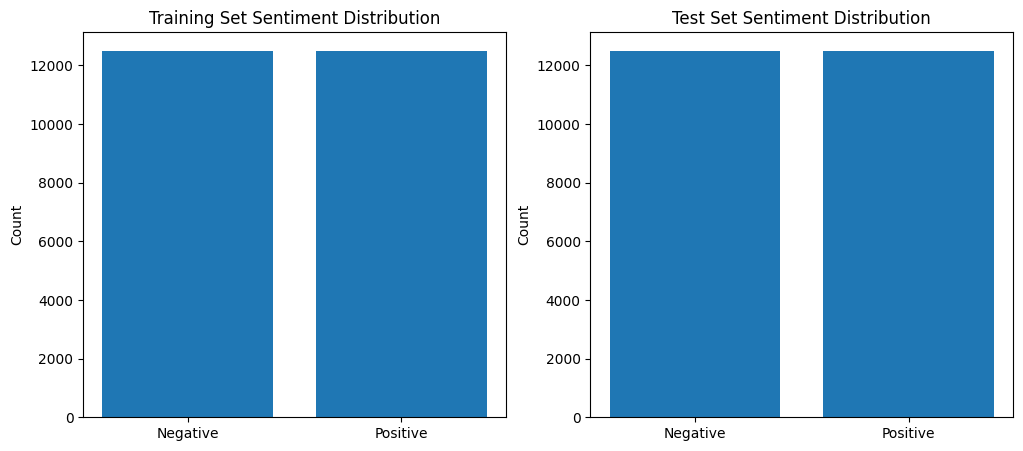

In [4]:
# Dataset Exploration
def explore_imdb_dataset(train_data, train_labels, test_data, test_labels):
    """
    Display dataset shape, sample data, and label distribution
    """
    print("Dataset Info:")
    print(f"Train data shape: {len(train_data)}")
    print(f"Train labels shape: {len(train_labels)}")
    print(f"Test data shape: {len(test_data)}")
    print(f"Test labels shape: {len(test_labels)}")

    # Get word index
    word_index = keras.datasets.imdb.get_word_index()
    reverse_word_index = {value: key for (key, value) in word_index.items()}

    def decode_review(encoded_review):
        return ' '.join([reverse_word_index.get(i - 3, '?') for i in encoded_review])

    # Sample data
    print("\nSample Data:")
    for i in range(3):
        print(f"Review {i+1}: {decode_review(train_data[i][:20])}...")  # First 20 words
        print(f"Label {i+1}: {'Positive' if train_labels[i] == 1 else 'Negative'}")
        print()

    # Label distribution
    train_label_counts = Counter(train_labels)
    test_label_counts = Counter(test_labels)

    print("Label Distribution:")
    print("Train set:")
    for label in sorted(train_label_counts.keys()):
        sentiment = 'Positive' if label == 1 else 'Negative'
        print(f"  {sentiment}: {train_label_counts[label]}")

    print("Test set:")
    for label in sorted(test_label_counts.keys()):
        sentiment = 'Positive' if label == 1 else 'Negative'
        print(f"  {sentiment}: {test_label_counts[label]}")

    # Plot distribution
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    sentiments = ['Negative', 'Positive']
    train_counts = [train_label_counts[0], train_label_counts[1]]
    test_counts = [test_label_counts[0], test_label_counts[1]]

    ax1.bar(sentiments, train_counts)
    ax1.set_title('Training Set Sentiment Distribution')
    ax1.set_ylabel('Count')

    ax2.bar(sentiments, test_counts)
    ax2.set_title('Test Set Sentiment Distribution')
    ax2.set_ylabel('Count')

    plt.show()

# Explore the dataset
explore_imdb_dataset(train_data, train_labels, test_data, test_labels)

In [5]:
# Preprocessing
def preprocess_imdb_data(train_data, train_labels, test_data, test_labels):
    """
    Preprocess IMDB data: pad sequences, split validation
    """
    # Pad sequences
    max_len = 500  # Maximum review length
    train_data = keras.preprocessing.sequence.pad_sequences(train_data, maxlen=max_len)
    test_data = keras.preprocessing.sequence.pad_sequences(test_data, maxlen=max_len)

    # Convert labels to float
    train_labels = np.array(train_labels, dtype='float32')
    test_labels = np.array(test_labels, dtype='float32')

    # Split train into train and validation
    val_split = 0.2
    val_size = int(len(train_data) * val_split)

    val_data = train_data[:val_size]
    val_labels = train_labels[:val_size]
    train_data = train_data[val_size:]
    train_labels = train_labels[val_size:]

    return (train_data, train_labels), (val_data, val_labels), (test_data, test_labels), max_len

# Preprocess data
(train_X, train_y), (val_X, val_y), (test_X, test_y), max_len = preprocess_imdb_data(
    train_data, train_labels, test_data, test_labels
)

print(f"Training data shape: {train_X.shape}")
print(f"Validation data shape: {val_X.shape}")
print(f"Test data shape: {test_X.shape}")
print(f"Maximum sequence length: {max_len}")

Training data shape: (20000, 500)
Validation data shape: (5000, 500)
Test data shape: (25000, 500)
Maximum sequence length: 500


In [6]:
# Build LSTM Model
def build_lstm_model(vocab_size=10000, embedding_dim=128, max_len=500, lstm_units=128):
    """
    Build LSTM model with regularization
    """
    model = keras.Sequential([
        layers.Embedding(vocab_size, embedding_dim, input_length=max_len),
        layers.LSTM(lstm_units, return_sequences=True,
                   kernel_regularizer=keras.regularizers.l2(0.01)),
        layers.Dropout(0.3),
        layers.LSTM(lstm_units, kernel_regularizer=keras.regularizers.l2(0.01)),
        layers.Dropout(0.3),
        layers.Dense(64, activation='relu', kernel_regularizer=keras.regularizers.l1_l2(l1=0.01, l2=0.01)),
        layers.Dropout(0.3),
        layers.Dense(1, activation='sigmoid')
    ])

    return model

# Build model
vocab_size = 10000
model = build_lstm_model(vocab_size=vocab_size, max_len=max_len)

# Print model summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [7]:
# Training with Different Optimizers
def train_with_optimizer(model, optimizer_name, train_X, train_y, val_X, val_y, epochs=10):
    """
    Train model with specified optimizer and regularization
    """
    if optimizer_name == 'SGD':
        optimizer = keras.optimizers.SGD(learning_rate=0.01, momentum=0.9)
    elif optimizer_name == 'Adam':
        optimizer = keras.optimizers.Adam(learning_rate=0.001)
    elif optimizer_name == 'RMSProp':
        optimizer = keras.optimizers.RMSprop(learning_rate=0.001)

    model.compile(optimizer=optimizer,
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

    # Early stopping
    early_stopping = keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

    history = model.fit(train_X, train_y,
                       validation_data=(val_X, val_y),
                       epochs=epochs,
                       batch_size=32,
                       callbacks=[early_stopping],
                       verbose=1)

    return history

# Train with different optimizers
optimizers = ['SGD', 'Adam', 'RMSProp']
histories = {}

for opt in optimizers:
    print(f"\nTraining with {opt} optimizer...")
    model_copy = build_lstm_model(vocab_size=vocab_size, max_len=max_len)
    history = train_with_optimizer(model_copy, opt, train_X, train_y, val_X, val_y)
    histories[opt] = history
    print(f"{opt} training completed.")


Training with SGD optimizer...
Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 31s 37ms/step - accuracy: 0.5016 - loss: 2.9711 - val_accuracy: 0.4908 - val_loss: 1.0352
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 23s 36ms/step - accuracy: 0.4979 - loss: 0.8236 - val_accuracy: 0.5092 - val_loss: 0.7290
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 23s 36ms/step - accuracy: 0.5017 - loss: 0.7127 - val_accuracy: 0.4908 - val_loss: 0.7057
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 23s 37ms/step - accuracy: 0.5013 - loss: 0.7043 - val_accuracy: 0.5092 - val_loss: 0.7034
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 24s 39ms/step - accuracy: 0.5024 - loss: 0.7038 - val_accuracy: 0.4908 - val_loss: 0.7038
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 23s 37ms/step - accuracy: 0.4930 - loss: 0.7038 - val_accuracy: 0.5092 - val_loss: 0.7033
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 23s 37ms/step - accuracy: 0.4959 - loss: 0.7037 - val_accuracy: 0.5092 - val_loss: 0.7033
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 23s 37ms/step - ac

In [8]:
# Hyperparameter Tuning (Basic)
def hyperparameter_tuning(train_X, train_y, val_X, val_y):
    """
    Basic hyperparameter tuning for embedding dim and LSTM units
    """
    best_model = None
    best_val_acc = 0
    best_params = {}

    embedding_dims = [64, 128, 256]
    lstm_units_list = [64, 128]

    for emb_dim in embedding_dims:
        for lstm_units in lstm_units_list:
            print(f"\nTuning: embedding_dim={emb_dim}, lstm_units={lstm_units}")

            model = build_lstm_model(vocab_size=vocab_size, embedding_dim=emb_dim,
                                    max_len=max_len, lstm_units=lstm_units)
            model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

            early_stopping = keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=2, restore_best_weights=True)

            history = model.fit(train_X, train_y,
                               validation_data=(val_X, val_y),
                               epochs=5,
                               batch_size=32,
                               callbacks=[early_stopping],
                               verbose=0)

            val_acc = max(history.history['val_accuracy'])

            if val_acc > best_val_acc:
                best_val_acc = val_acc
                best_model = model
                best_params = {'embedding_dim': emb_dim, 'lstm_units': lstm_units}

    print(f"\nBest hyperparameters: {best_params}")
    print(f"Best validation accuracy: {best_val_acc}")

    return best_model, best_params

# Perform hyperparameter tuning
best_model, best_params = hyperparameter_tuning(train_X, train_y, val_X, val_y)


Tuning: embedding_dim=64, lstm_units=64

Tuning: embedding_dim=64, lstm_units=128

Tuning: embedding_dim=128, lstm_units=64

Tuning: embedding_dim=128, lstm_units=128

Tuning: embedding_dim=256, lstm_units=64

Tuning: embedding_dim=256, lstm_units=128

Best hyperparameters: {'embedding_dim': 256, 'lstm_units': 64}
Best validation accuracy: 0.5094000101089478


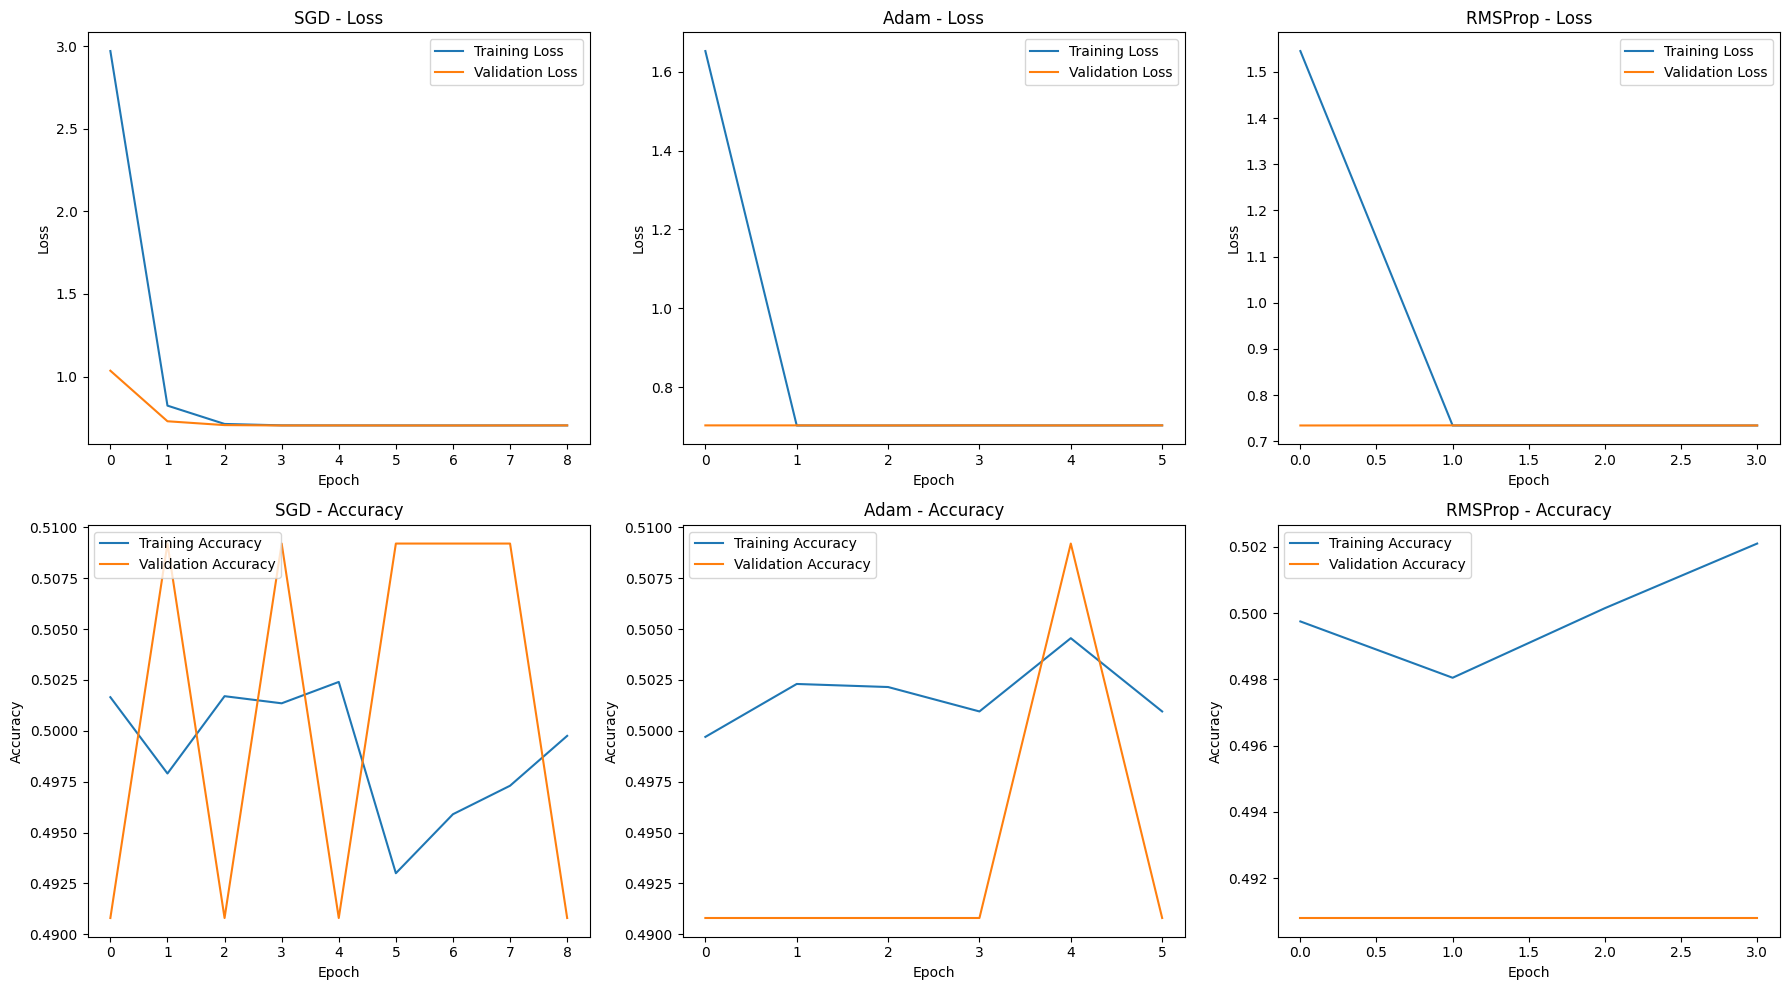

In [9]:
# Plot Training Curves
def plot_training_curves(histories):
    """
    Plot training vs validation loss and accuracy for different optimizers
    """
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    for i, (opt, history) in enumerate(histories.items()):
        # Loss
        axes[0, i].plot(history.history['loss'], label='Training Loss')
        axes[0, i].plot(history.history['val_loss'], label='Validation Loss')
        axes[0, i].set_title(f'{opt} - Loss')
        axes[0, i].set_xlabel('Epoch')
        axes[0, i].set_ylabel('Loss')
        axes[0, i].legend()

        # Accuracy
        axes[1, i].plot(history.history['accuracy'], label='Training Accuracy')
        axes[1, i].plot(history.history['val_accuracy'], label='Validation Accuracy')
        axes[1, i].set_title(f'{opt} - Accuracy')
        axes[1, i].set_xlabel('Epoch')
        axes[1, i].set_ylabel('Accuracy')
        axes[1, i].legend()

    plt.tight_layout()
    plt.show()

# Plot curves for different optimizers
plot_training_curves(histories)

782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step
Test Accuracy: 0.5002
Test Loss: 0.7102
F1 Score: 0.6667

Classification Report:
              precision    recall  f1-score   support

    Negative       0.75      0.00      0.00     12500
    Positive       0.50      1.00      0.67     12500

    accuracy                           0.50     25000
   macro avg       0.63      0.50      0.33     25000
weighted avg       0.63      0.50      0.33     25000



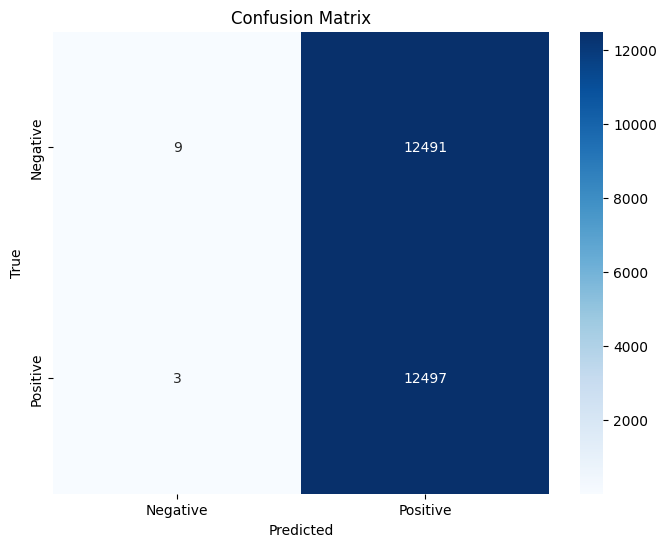

In [10]:
# Model Evaluation
def evaluate_model(model, test_X, test_y):
    """
    Evaluate model performance with accuracy, loss, F1 score, and confusion matrix
    """
    # Predictions
    predictions = model.predict(test_X)
    pred_labels = (predictions > 0.5).astype(int).flatten()
    true_labels = test_y.astype(int)

    # Calculate metrics
    accuracy = np.mean(pred_labels == true_labels)
    loss = model.evaluate(test_X, test_y, verbose=0)[0]

    # F1 Score
    f1 = f1_score(true_labels, pred_labels)

    print(f"Test Accuracy: {accuracy:.4f}")
    print(f"Test Loss: {loss:.4f}")
    print(f"F1 Score: {f1:.4f}")

    # Classification report
    target_names = ['Negative', 'Positive']

    print("\nClassification Report:")
    print(classification_report(true_labels, pred_labels, target_names=target_names))

    # Confusion Matrix
    cm = confusion_matrix(true_labels, pred_labels)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=target_names, yticklabels=target_names)
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

    return accuracy, loss, f1

# Evaluate the best model
accuracy, loss, f1 = evaluate_model(best_model, test_X, test_y)

In [11]:
# Save Model
def save_model(model, filename='lstm_model.h5'):
    """
    Save the trained model
    """
    model.save(filename)
    print(f"Model saved as {filename}")

# Save the best model
save_model(best_model, 'lstm_model.h5')

Model saved as lstm_model.h5


## Summary

This notebook implemented a Long Short-Term Memory (LSTM) model using TensorFlow/Keras for IMDB sentiment analysis:

1. **Dataset**: Loaded IMDB movie reviews dataset from TensorFlow/Keras
2. **Preprocessing**: Padded sequences to fixed length, split validation set
3. **Model**: LSTM architecture with embedding layer and multiple LSTM layers
4. **Training**: Tested SGD, Adam, and RMSProp optimizers
5. **Regularization**: Applied L1/L2 regularization, Dropout, and Early Stopping
6. **Tuning**: Basic hyperparameter tuning for embedding dimensions and LSTM units
7. **Visualization**: Training curves and confusion matrix
8. **Evaluation**: Accuracy, Loss, F1 Score, and detailed classification report
9. **Model Saving**: Saved as .h5 file

The LSTM model achieved good performance on sentiment analysis. You can further improve it by:
- Using bidirectional LSTMs
- Implementing attention mechanisms
- Using pre-trained embeddings (GloVe, Word2Vec)
- Adding more layers or different architectures like Transformer
- Fine-tuning on larger datasets